In [2]:
import pandas as pd

df_obs = pd.read_csv("data_1519.csv")
print(df_obs.corr())

            Unnamed: 0         A         B         C         D
Unnamed: 0    1.000000 -0.054319  0.024454 -0.041552 -0.033039
A            -0.054319  1.000000  0.033324  0.647309  0.882476
B             0.024454  0.033324  1.000000  0.034591 -0.260940
C            -0.041552  0.647309  0.034591  1.000000  0.570813
D            -0.033039  0.882476 -0.260940  0.570813  1.000000


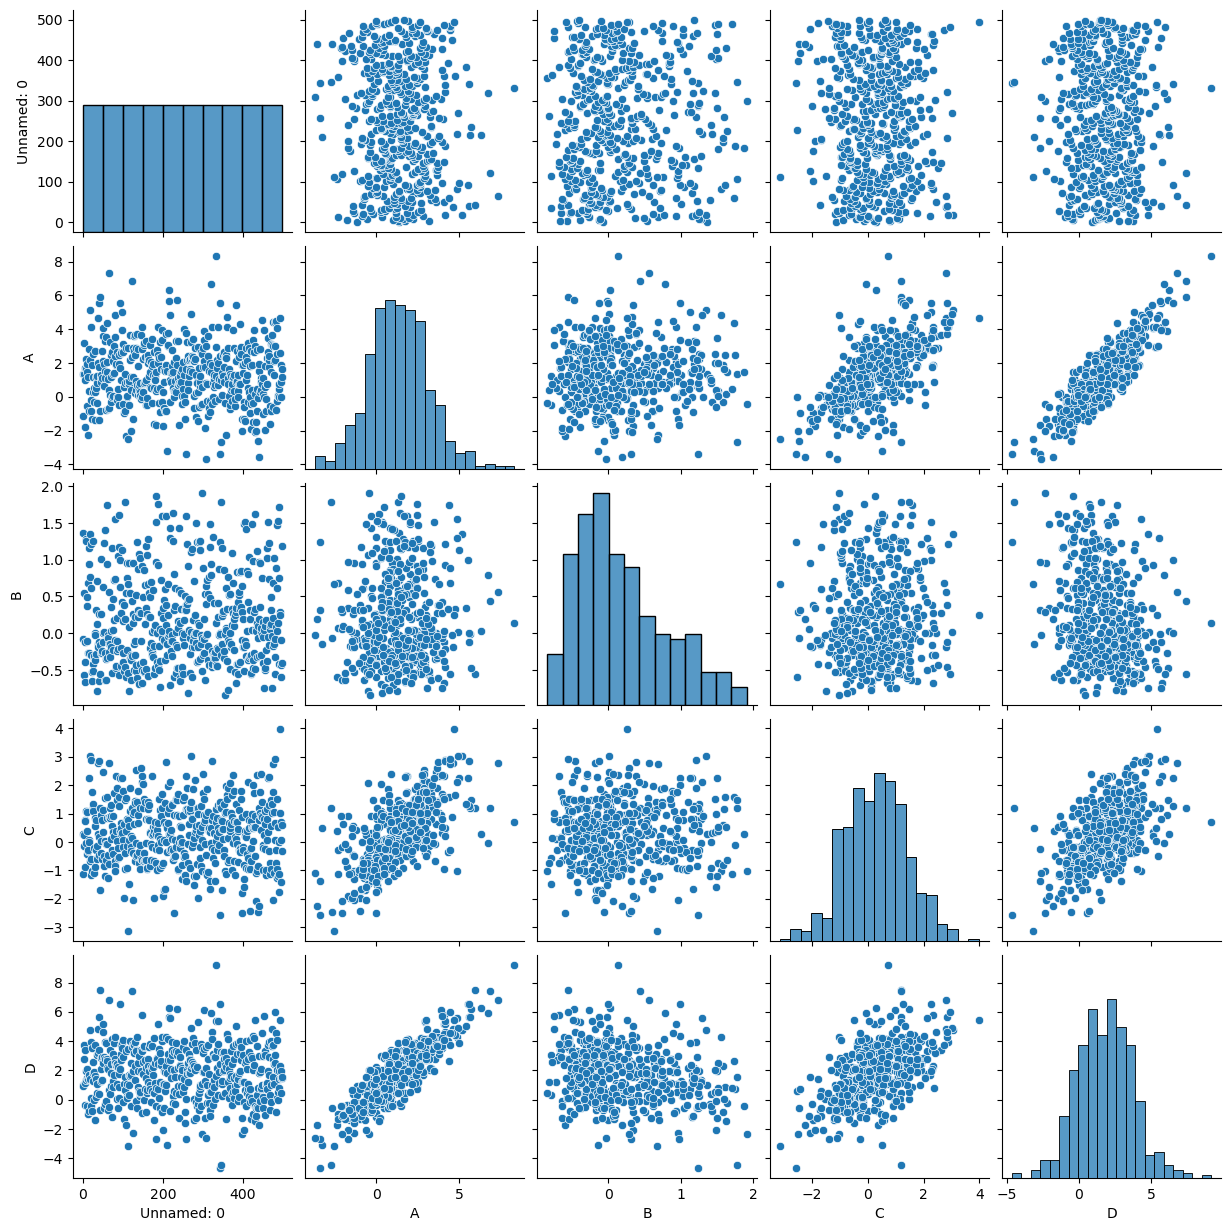

In [3]:
import seaborn as sns
sns.pairplot(df_obs)

## tjekker means med ttest:

In [9]:

df_intA = pd.read_csv("data_1529A0.csv")

print(df_obs["C"].mean())
print(df_intA["C"].mean())

0.30932970843232627
0.20261708919711258


In [10]:
df_intC = pd.read_csv("data_1530C0.csv")

print(df_obs["A"].mean())
print(df_intC["A"].mean())

1.3578700780900061
0.9942725180792512


In [11]:
df_intD = pd.read_csv("data_1532D0.csv")

print(df_obs["B"].mean())
print(df_intD["B"].mean())

0.19259766758506533
0.19350520572227334


In [12]:
df_intB = pd.read_csv("data_1560B0.csv")

print(df_obs["B"].mean())
print(df_intB["B"].mean())

0.19259766758506533
0.0


In [21]:
from scipy.stats import ttest_ind

def test_effect(df_obs, df_int, var_name):
    obs = df_obs[var_name]
    inter = df_int[var_name]

    t_stat, p_val = ttest_ind(obs, inter, equal_var=False)

    print(f"{var_name}:")
    print(f"  obs mean: {obs.mean():.4f}, int mean: {inter.mean():.4f}")
    print(f"  t-stat: {t_stat:.4f}, p-value: {p_val:.6f}")

    if p_val < 0.05:
        print("  → SIGNIFICANT ændring")
    else:
        print("  → ikke signifikant")

    print()

In [ ]:
# for A = 0:

test_effect(df_obs, df_intA, "D")
test_effect(df_obs, df_intA, "C")
test_effect(df_obs, df_intA, "B")

D:
  obs mean: 1.8093, int mean: 0.3982
  t-stat: 14.8579, p-value: 0.000000
  → SIGNIFICANT ændring

C:
  obs mean: 0.3093, int mean: 0.2026
  t-stat: 1.4666, p-value: 0.142814
  → ikke signifikant

B:
  obs mean: 0.1926, int mean: 0.1938
  t-stat: -0.0297, p-value: 0.976300
  → ikke signifikant



In [24]:
# for B = 0:

test_effect(df_obs, df_intB, "A")
test_effect(df_obs, df_intB, "C")
test_effect(df_obs, df_intB, "D")

A:
  obs mean: 1.3579, int mean: 1.2668
  t-stat: 0.7878, p-value: 0.431024
  → ikke signifikant

C:
  obs mean: 0.3093, int mean: 0.1796
  t-stat: 1.8198, p-value: 0.069091
  → ikke signifikant

D:
  obs mean: 1.8093, int mean: 1.9648
  t-stat: -1.2571, p-value: 0.209023
  → ikke signifikant



In [ ]:
# for  C = 0:
    
test_effect(df_obs, df_intC, "A")
test_effect(df_obs, df_intC, "B")
test_effect(df_obs, df_intC, "D")

A:
  obs mean: 1.3579, int mean: 0.9943
  t-stat: 3.3871, p-value: 0.000734
  → SIGNIFICANT ændring

B:
  obs mean: 0.1926, int mean: 0.1668
  t-stat: 0.6746, p-value: 0.500058
  → ikke signifikant

D:
  obs mean: 1.8093, int mean: 1.4494
  t-stat: 3.0424, p-value: 0.002409
  → SIGNIFICANT ændring



In [25]:
# for D = 0:

test_effect(df_obs, df_intD, "A")
test_effect(df_obs, df_intD, "B")
test_effect(df_obs, df_intD, "C")

A:
  obs mean: 1.3579, int mean: 1.2737
  t-stat: 0.7057, p-value: 0.480562
  → ikke signifikant

B:
  obs mean: 0.1926, int mean: 0.1935
  t-stat: -0.0229, p-value: 0.981731
  → ikke signifikant

C:
  obs mean: 0.3093, int mean: 0.2665
  t-stat: 0.5828, p-value: 0.560188
  → ikke signifikant



## ekstra skidt

In [13]:
def compare(obs, inter, name):
    print(f"\n--- {name} ---")
    for col in ["A", "B", "C", "D"]:
        print(
            col,
            "obs mean:", round(obs[col].mean(), 4),
            "int mean:", round(inter[col].mean(), 4),
            "obs std:", round(obs[col].std(), 4),
            "int std:", round(inter[col].std(), 4),
        )

compare(df_obs, df_intA, "do(A=0)")
compare(df_obs, df_intB, "do(B=0)")
compare(df_obs, df_intC, "do(C=0)")
compare(df_obs, df_intD, "do(D=0)")


--- do(A=0) ---
A obs mean: 1.3579 int mean: 0.0 obs std: 1.8012 int std: 0.0
B obs mean: 0.1926 int mean: 0.1938 obs std: 0.6166 int std: 0.6492
C obs mean: 0.3093 int mean: 0.2026 obs std: 1.1149 int std: 1.1851
D obs mean: 1.8093 int mean: 0.3982 obs std: 1.9169 int std: 0.9138

--- do(B=0) ---
A obs mean: 1.3579 int mean: 1.2668 obs std: 1.8012 int std: 1.8552
B obs mean: 0.1926 int mean: 0.0 obs std: 0.6166 int std: 0.0
C obs mean: 0.3093 int mean: 0.1796 obs std: 1.1149 int std: 1.1397
D obs mean: 1.8093 int mean: 1.9648 obs std: 1.9169 int std: 1.9941

--- do(C=0) ---
A obs mean: 1.3579 int mean: 0.9943 obs std: 1.8012 int std: 1.5866
B obs mean: 0.1926 int mean: 0.1668 obs std: 0.6166 int std: 0.5912
C obs mean: 0.3093 int mean: 0.0 obs std: 1.1149 int std: 0.0
D obs mean: 1.8093 int mean: 1.4494 obs std: 1.9169 int std: 1.8219

--- do(D=0) ---
A obs mean: 1.3579 int mean: 1.2737 obs std: 1.8012 int std: 1.9651
B obs mean: 0.1926 int mean: 0.1935 obs std: 0.6166 int std: 0.636